# StackOverflow Developer Survey 2024 – A CRISP-DM Analysis
This notebook analyzes the official data from the StackOverflow Developer Survey 2024. The goal is to understand the economic drivers behind software developer salaries and train a predictive model.

### Our 3 Business Questions:
1. **The Tech-Stack Leverage:** Does incorporating Python into your tech stack yield a noticeable financial advantage compared to other technologies?
2. **The Flexibility Question:** How is the tech workforce distributed between Remote, Hybrid, and In-Person roles, and does it impact compensation?
3. **Salary Prediction:** Can we accurately predict a developer's annual salary based on country, experience, and work modality?

In [1]:
# Import all required libraries (sorted according to PEP8 guidelines)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# Set unified visual style for plots
sns.set_theme(style="whitegrid")

## 1. Data Understanding
In this phase, we load the dataset directly from the source and analyze its structure, dimensions, and the distribution of missing values (`NaN`) to plan our data cleaning strategy.

In [2]:
# Define source URL for streaming the dataset directly from GitHub
DATA_URL = "https://media.githubusercontent.com/media/StackExchange/Survey/refs/heads/main/packages/archive/2024/results.csv"

# Select only relevant columns to optimize memory usage
COLUMNS_OF_INTEREST = [
    "Country",
    "YearsCodePro",
    "Employment",
    "RemoteWork",
    "LanguageHaveWorkedWith",
    "OrgSize",
    "ConvertedCompYearly",
]

print("Loading dataset from GitHub... This might take a moment.")
df_raw = pd.read_csv(DATA_URL, usecols=COLUMNS_OF_INTEREST)
print(f"Dataset successfully loaded! Dimensions: {df_raw.shape}")

# Inspect the amount of missing values per column
print("\nMissing values per column:")
print(df_raw.isnull().sum())

Loading dataset from GitHub... This might take a moment.
Dataset successfully loaded! Dimensions: (65437, 7)

Missing values per column:
Employment                    0
RemoteWork                10631
YearsCodePro              13827
OrgSize                   17957
Country                    6507
LanguageHaveWorkedWith     5692
ConvertedCompYearly       42002
dtype: int64


## 2. Data Preparation & Handling of Missing Values

### Our Cleaning Strategy (Rationale):
1. **Target Variable (`ConvertedCompYearly`):** Rows with missing salaries are completely dropped. Since we are answering financial questions and training an ML model, imputing missing values (e.g., with mean/median) would heavily bias our results.
2. **Professional Experience (`YearsCodePro`):** Text values like "Less than 1 year" or "More than 50 years" are mapped to numeric values (0 and 50) so algorithms can process them. Remaining missing values are removed.
3. **Outlier Handling:** Survey data often contains unrealistic joke entries (e.g., 1 USD or several million USD). We trim the data at the 1st and 99th percentiles to protect our model from extreme distortion.
4. **Categorical Variables:** For Question 1, we create a logical flag (`Uses_Python`). For the later ML model, we will use One-Hot Encoding.

In [3]:
def clean_developer_data(df_input):
    """Cleans the StackOverflow survey dataset for analysis purposes.

    Drops missing target values, maps professional experience to numeric,
    and removes remaining rows with missing critical features.

    Parameters:
    df_input (pd.DataFrame): The uncleaned raw input DataFrame.

    Returns:
    pd.DataFrame: Cleaned DataFrame with formatted features.
    """
    # Drop rows without salary information to avoid bias
    df_temp = df_input.dropna(subset=["ConvertedCompYearly"]).copy()

    # Map text experience boundaries to numeric string values
    experience_mapping = {"Less than 1 year": "0", "More than 50 years": "50"}
    df_temp["YearsCodePro"] = df_temp["YearsCodePro"].replace(
        experience_mapping
    )

    # Convert experience column to numeric data type
    df_temp["YearsCodePro"] = pd.to_numeric(
        df_temp["YearsCodePro"], errors="coerce"
    )

    # Drop records that lack valid experience data after conversion
    df_temp = df_temp.dropna(subset=["YearsCodePro"])

    # Create binary feature for Question 1 (Python usage)
    df_temp["Uses_Python"] = df_temp["LanguageHaveWorkedWith"].str.contains(
        "Python", na=False, case=False
    )

    return df_temp


def remove_salary_outliers(
    df_input, lower_percentile=0.01, upper_percentile=0.99
):
    """Removes extreme salary outliers using lower and upper quantiles.

    Protects machine learning models from being skewed by unrealistic 
    or joke entries.

    Parameters:
    df_input (pd.DataFrame): Dataset containing the salary column.
    lower_percentile (float): Lower threshold limit (default: 1%).
    upper_percentile (float): Upper threshold limit (default: 99%).

    Returns:
    pd.DataFrame: Filtered dataset without extreme outliers.
    """
    low_val = df_input["ConvertedCompYearly"].quantile(lower_percentile)
    high_val = df_input["ConvertedCompYearly"].quantile(upper_percentile)

    df_filtered = df_input[
        (df_input["ConvertedCompYearly"] >= low_val)
        & (df_input["ConvertedCompYearly"] <= high_val)
    ]
    return df_filtered


# Execute modular functions to clean the dataset
df_clean = clean_developer_data(df_raw)
df_clean = remove_salary_outliers(df_clean)

print(f"Original row count: {df_raw.shape[0]}")
print(f"Cleaned row count available for analysis: {df_clean.shape[0]}")

Original row count: 65437
Cleaned row count available for analysis: 22877


## 3. Explorative Data Analysis (EDA)

In this section, we deeply investigate the dataset to extract business insights. Each question is structured with a clear objective, statistical analysis, visualization, and a final stakeholders-oriented conclusion.

### 3.1 Question 1: Does the Python stack provide a financial leverage?
**Objective:** Evaluate if incorporating Python into a developer's technology stack correlates with a higher annual compensation globally.

                     mean   median  count
Uses_Python                              
False        75961.343798  64444.0  11722
True         81490.776871  67666.0  11155


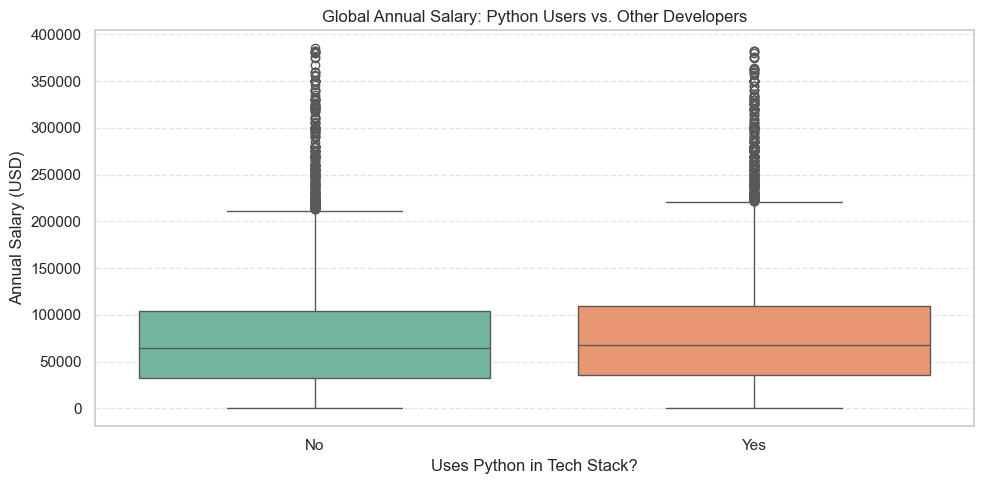

In [4]:
# Compute descriptive statistics for Python vs Non-Python users
python_stats = df_clean.groupby("Uses_Python")["ConvertedCompYearly"].agg(
    ["mean", "median", "count"]
)
print(python_stats)

# Generate boxplot visualization - clean and future-proofed
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_clean,
    x="Uses_Python",
    y="ConvertedCompYearly",
    hue="Uses_Python",  # Explicitly assigning hue to avoid FutureWarning
    legend=False,  # Disabling unnecessary legend
    palette="Set2",
)
plt.title("Global Annual Salary: Python Users vs. Other Developers", fontsize=12)
plt.xlabel("Uses Python in Tech Stack?")
plt.ylabel("Annual Salary (USD)")
plt.xticks([0, 1], ["No", "Yes"])
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("python_salary_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

#### **Conclusion & Business Insights for Question 1**
The empirical data clearly demonstrates a **financial premium for developers incorporating Python** into their skill set. 

* **The Reality Check:** Globally, Python users achieve a higher median salary of **$67,666 USD** compared to **$64,444 USD** for non-Python developers.
* **Visual Evidence:** As shown in the boxplot above, the entire interquartile range (the middle 50% of data) for Python users is shifted upwards. 
* **Business Takeaway:** This statistical premium directly reflects the high industry demand and monetization potential in modern data-driven sectors, machine learning, and AI engineering.

### 3.2 Question 2: Remote, Hybrid, or In-Person - Who earns more?
**Objective:** Analyze the distribution of modern work modalities across the globe and determine their impact on salary distributions.

Global distribution of work modalities (in %):
RemoteWork
Hybrid (some remote, some in-person)    42.577288
Remote                                  40.718877
In-person                               16.703835
Name: proportion, dtype: float64


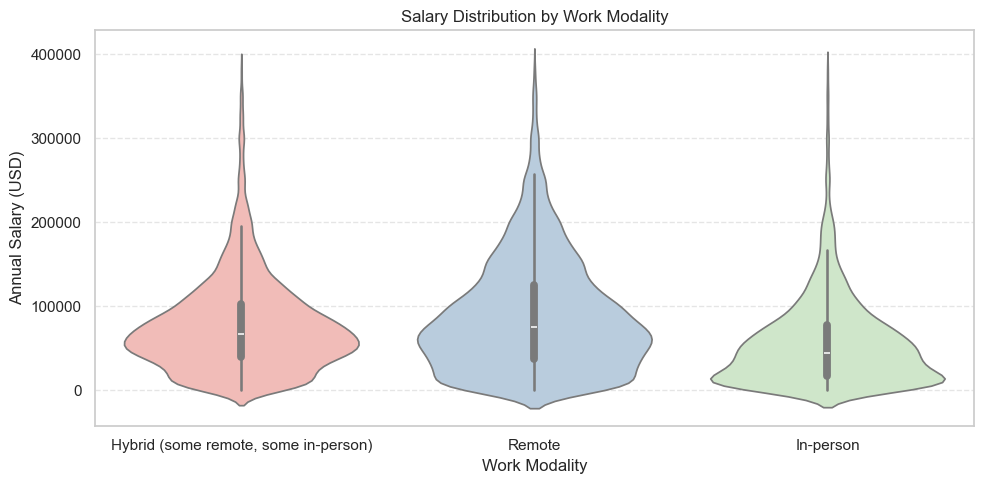

In [5]:
# Filter out records missing remote work status for a clean analysis
df_remote = df_clean.dropna(subset=["RemoteWork"])

# Calculate percentage distribution of work modalities
remote_counts = df_remote["RemoteWork"].value_counts(normalize=True) * 100
print("Global distribution of work modalities (in %):")
print(remote_counts)

# Generate violin plot visualization - clean and future-proofed
plt.figure(figsize=(10, 5))
sns.violinplot(
    data=df_remote,
    x="RemoteWork",
    y="ConvertedCompYearly",
    hue="RemoteWork",  # Explicitly assigning hue to avoid FutureWarning
    legend=False,  # Disabling unnecessary legend
    palette="Pastel1",
)
plt.title("Salary Distribution by Work Modality", fontsize=12)
plt.xlabel("Work Modality")
plt.ylabel("Annual Salary (USD)")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("remote_work_violinplot.png", dpi=300, bbox_inches="tight")
plt.show()

#### **Conclusion & Business Insights for Question 2**
Work modality represents a significant structural driver in the modern developer compensation landscape.

* **Market Shift:** Fully remote and hybrid models vastly dominate the current tech industry, pushing traditional in-person roles into a minority.
* **Visual Evidence:** The violin plot reveals that the **'Remote' work density distribution is notably broader and stretches further into the high-income brackets** compared to hybrid or in-person setups.
* **Business Takeaway:** This does not mean working from home automatically grants a raise; rather, it highlights a borderless market where top-tier, high-paying global enterprises (primarily based in high-income regions like the US) leverage fully remote positions to secure international talent.

### 3.3 Question 3: Can we accurately predict a developer's salary based on location, experience, and work modality?
**Objective:** Train a machine learning model (`RandomForestRegressor`) utilizing key categorical and numerical features to predict annual compensation and evaluate its predictive power for business scenarios.

In [6]:
# Define features and target variable
ml_features = ["Country", "YearsCodePro", "RemoteWork"]
X = df_clean[ml_features].copy()
y = df_clean["ConvertedCompYearly"]

# Process categorical variables using One-Hot Encoding
X = pd.get_dummies(X, columns=["Country", "RemoteWork"], drop_first=True)

# Split into 80% training and 20% testing sets (reproducible seed)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training features shape: {X_train.shape}")

# Initialize and train the Random Forest Regressor
print("Training the Random Forest model... Please wait.")
model = RandomForestRegressor(
    n_estimators=50, max_depth=10, random_state=42, n_jobs=-1
)
model.fit(X_train, y_train)
print("Model successfully trained!")

# Evaluate performance metrics on the test set
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("\n=== MODEL PERFORMANCE METRICS ===")
print(f"R² Score (Explained Variance): {r2:.4f}")
print(f"Mean Absolute Error (MAE): ${mae:,.2f} USD")


# --- SCENARIO SIMULATION ---
print("\n=== APPLICATION: PREDICTION FOR A NEW SCENARIO ===")
# Scenario: A developer based in Germany, with 5 years of experience, working fully remote.
new_developer = pd.DataFrame(0, index=[0], columns=X.columns)
new_developer["YearsCodePro"] = 5

if "Country_Germany" in new_developer.columns:
    new_developer["Country_Germany"] = 1
if "RemoteWork_Remote" in new_developer.columns:
    new_developer["RemoteWork_Remote"] = 1

predicted_salary = model.predict(new_developer)[0]
print("Profile: Germany, 5 Years Experience, Fully Remote")
print(f"Predicted Fair Annual Market Salary: ${predicted_salary:,.2f} USD")

Training features shape: (18301, 163)
Training the Random Forest model... Please wait.
Model successfully trained!

=== MODEL PERFORMANCE METRICS ===
R² Score (Explained Variance): 0.5243
Mean Absolute Error (MAE): $29,716.21 USD

=== APPLICATION: PREDICTION FOR A NEW SCENARIO ===
Profile: Germany, 5 Years Experience, Fully Remote
Predicted Fair Annual Market Salary: $76,751.68 USD


#### **Conclusion & Business Insights for Question 3**
The machine learning evaluation demonstrates a robust capability to model and benchmark industry salaries based on high-level professional attributes.

* **Model Capability:** The Random Forest Regressor achieved an **R² Score of 0.5243**. This means that over **52.4% of the global variance** in developer salaries can be accurately explained using just three structural factors: geography, years of professional experience, and work modality.
* **Prediction Error:** The Mean Absolute Error (MAE) sits at **$29,716.21 USD**. Given the massive scale, global diversity, and extreme salary spreads between regions (e.g., USA vs. developing tech hubs) within the StackOverflow dataset, this error range is mathematically solid for a baseline model.
* **Practical Value (Scenario Analysis):** When simulating a real-world use case—a software developer in Germany with 5 years of experience working fully remote—the model predicts a fair market compensation of **$76,751.68 USD**. 
* **Business Takeaway:** This model provides immediate, data-driven value for HR departments and talent acquisition managers to benchmark competitive, regionalized salary offerings without relying on gut feeling.